### Simple Exponential Smoothing (SES)

##### SES is a forecasting method that predicts the next value based on a weighted average of all past values, where more recent values are given more weight and older values are given less weight.

##### The weight is controlled by alpha (α):

##### Alpha close to 1 → model trusts recent data more (reacts quickly to changes)

##### Alpha close to 0 → model trusts older data more (smoother, slower to react)


##### The key limitation of SES is that it only captures the level of the data. It works best when the data has no trend and no seasonality, it essentially just smooths out the noise and predicts a flat line forward.

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import datetime as dt

In [3]:
start = dt.datetime(2021,7,1)
end = dt.datetime(2022,1,28)

stk_data = yf.download("RELIANCE.NS", start=start, end=end)

[*********************100%***********************]  1 of 1 completed


In [4]:
stk_data

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2021-07-01,954.592529,966.058798,953.250218,963.715501,12534407
2021-07-02,968.743286,970.495102,952.317341,954.160145,14086620
2021-07-05,978.366882,979.891169,969.858139,972.110448,11702287
2021-07-06,966.809570,977.775346,964.716550,975.978096,10070124
2021-07-07,960.098083,968.151828,954.615226,968.151828,10454892
...,...,...,...,...,...
2022-01-20,1127.269653,1142.057580,1117.054587,1137.552961,16494486
2022-01-21,1127.451660,1138.553979,1115.689680,1115.689680,13338594


In [5]:
# The dataframe is not normal columns, it's a MultiIndex (two-level columns).
# So, flattening the columns:

stk_data.columns = stk_data.columns.get_level_values(0)

In [6]:
stk_data

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-07-01,954.592529,966.058798,953.250218,963.715501,12534407
2021-07-02,968.743286,970.495102,952.317341,954.160145,14086620
2021-07-05,978.366882,979.891169,969.858139,972.110448,11702287
2021-07-06,966.809570,977.775346,964.716550,975.978096,10070124
2021-07-07,960.098083,968.151828,954.615226,968.151828,10454892
...,...,...,...,...,...
2022-01-20,1127.269653,1142.057580,1117.054587,1137.552961,16494486
2022-01-21,1127.451660,1138.553979,1115.689680,1115.689680,13338594
2022-01-24,1081.973145,1139.691425,1071.598850,1126.154703,21868937


In [7]:
stk_data = stk_data[["Open", "High", "Low", "Close"]]

In [8]:
stk_data

Price,Open,High,Low,Close
Date,,,,
2021-07-01,963.715501,966.058798,953.250218,954.592529
2021-07-02,954.160145,970.495102,952.317341,968.743286
2021-07-05,972.110448,979.891169,969.858139,978.366882
2021-07-06,975.978096,977.775346,964.716550,966.809570
2021-07-07,968.151828,968.151828,954.615226,960.098083
...,...,...,...,...
2022-01-20,1137.552961,1142.057580,1117.054587,1127.269653
2022-01-21,1115.689680,1138.553979,1115.689680,1127.451660
2022-01-24,1126.154703,1139.691425,1071.598850,1081.973145


In [9]:
column = "Close"

In [10]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1 = Ms.fit_transform(stk_data[[column]])
print("Len:", data1.shape)

Len: (144, 1)


In [11]:
len(data1)

144

In [12]:
training_size = round(len(data1) * 0.80)
print(training_size)

X_train = data1[:training_size]
X_test = data1[training_size:]
print("X_train length:", X_train.shape)
print("X_test length:", X_test.shape)

y_train = data1[:training_size]
y_test = data1[training_size:]
print("y_train length:", y_train.shape)
print("y_test length:", y_test.shape)

115
X_train length: (115, 1)
X_test length: (29, 1)
y_train length: (115, 1)
y_test length: (29, 1)


In [13]:
# Import required libraries
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from stockFunctions import rmsemape

# Define smoothing level (alpha) values to tune
alphas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Loop through alpha values
for alpha in alphas:

    # Build model
    model = SimpleExpSmoothing(X_train)
    model_fit = model.fit(smoothing_level=alpha, optimized=False)

    # Make predictions on test set
    y_pred = model_fit.forecast(len(X_test))

    # Print results
    print("Alpha={}".format(alpha))
    rmsemape(y_test, y_pred)
    print("*****************")

Alpha=0.1
RMSE-Testset: 0.10550756914035085
MAPE-Testset: 0.1745915140799689
*****************
Alpha=0.2
RMSE-Testset: 0.1070061498342012
MAPE-Testset: 0.161406378380034
*****************
Alpha=0.3
RMSE-Testset: 0.10908744982654386
MAPE-Testset: 0.15860309326204097
*****************
Alpha=0.4
RMSE-Testset: 0.11060076883944513
MAPE-Testset: 0.1581002201116102
*****************
Alpha=0.5
RMSE-Testset: 0.11153666048925849
MAPE-Testset: 0.15817958652156866
*****************
Alpha=0.6
RMSE-Testset: 0.11178813153804688
MAPE-Testset: 0.15819999617885855
*****************
Alpha=0.7
RMSE-Testset: 0.11138987022620965
MAPE-Testset: 0.1581675051390105
*****************
Alpha=0.8
RMSE-Testset: 0.11052303023385619
MAPE-Testset: 0.15809335851749576
*****************
Alpha=0.9
RMSE-Testset: 0.10942859951861889
MAPE-Testset: 0.15847267379863525
*****************


In [14]:
# Best model: Alpha=0.9 (example — choose based on lowest RMSE/MAPE from tuning above)
# Reason: Higher alpha gives more weight to recent observations → better for trending stock prices

alpha = 0.9

# Build model
model = SimpleExpSmoothing(X_train)
model_fit = model.fit(smoothing_level=alpha, optimized=False)

# Make predictions
y_pred = model_fit.forecast(len(X_test))

print("Alpha={}".format(alpha))
rmsemape(y_test, y_pred)
print("*****************")

Alpha=0.9
RMSE-Testset: 0.10942859951861889
MAPE-Testset: 0.15847267379863525
*****************


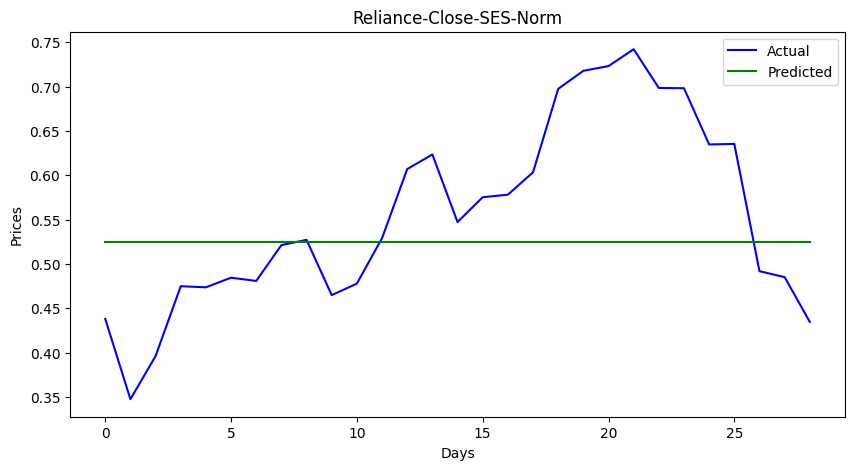

In [15]:
from stockFunctions import graph
graph(y_test, y_pred, "Actual", "Predicted", "Reliance-Close-SES-Norm", "Days", "Prices")

In [16]:
from stockFunctions import conversionSingle

aTestNormTable = conversionSingle(y_test, [column])
actual_stock_price_test_ori = Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA = conversionSingle(actual_stock_price_test_ori, [column])

In [17]:
from stockFunctions import conversionSingle

pTestNormTable = conversionSingle(y_pred, [column])
predicted_stock_price_test_ori = Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP = conversionSingle(predicted_stock_price_test_ori, [column])

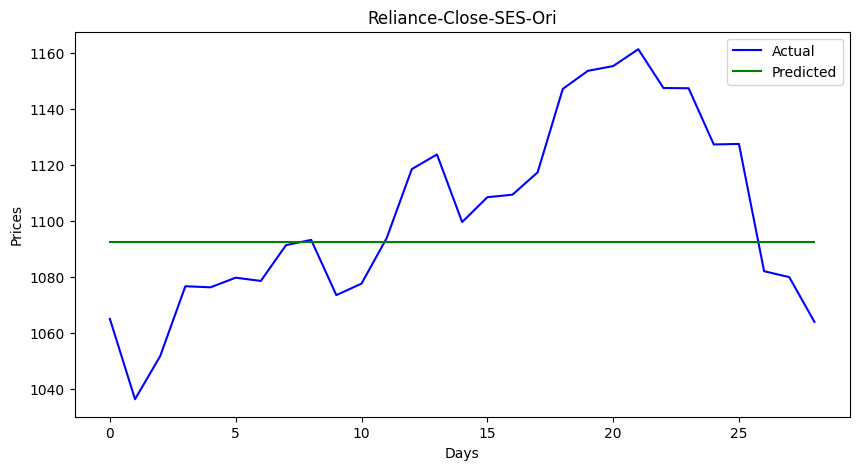

In [18]:
from stockFunctions import graph

graph(actual_stock_price_test_oriA,
      predicted_stock_price_test_oriP,
      "Actual",
      "Predicted",
      "Reliance-Close-SES-Ori",
      "Days",
      "Prices")

In [19]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA, predicted_stock_price_test_oriP)

RMSE-Testset: 34.682146981782346
MAPE-Testset: 0.025435379718555223


In [20]:
# Forecast next 4 days beyond the dataset
forecast = model_fit.forecast(4)

In [21]:
forecast

array([0.52492078, 0.52492078, 0.52492078, 0.52492078])

In [22]:
from stockFunctions import conversionSingle

fTestNormTable = conversionSingle(forecast, ["Closefore"])
forecast_stock_price_test_ori = Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF = conversionSingle(forecast_stock_price_test_ori, ["Closefore"])

In [23]:
forecast_stock_price_test_oriF

,Closefore
0,1092.453717
1,1092.453717
2,1092.453717
3,1092.453717


In [24]:
forecast_stock_price_test_oriF.to_csv("CloseSES.csv", index=False)

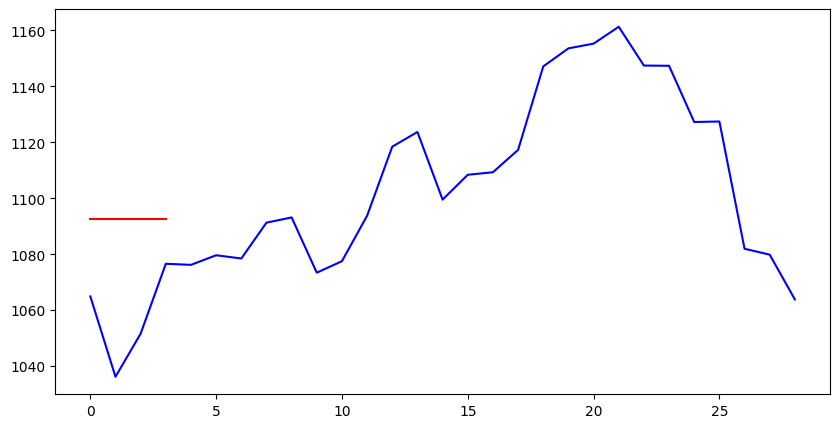

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(actual_stock_price_test_oriA, color='blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF, color='red', label="Forecast")